In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Load dataset
df = pd.read_csv('customer_support_text_classification.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nTarget distribution:")
print(df.iloc[:, -1].value_counts())
print("\nAverage text length:")
print(df.iloc[:, 1].apply(len).mean())

[nltk_data] Downloading package stopwords to /Users/shlok/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /Users/shlok/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /Users/shlok/nltk_data...


Shape: (1500, 6)

Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

First 3 rows:
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  

Target distribution:
urgent_flag
0    1100
1     400
Name: count, dtype: int64

Average text length:
4.650666666666667


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Task 1: Dataset Understanding
- **Shape:** 1500 rows, 6 columns
- **Text column:** `customer_message`
- **Target:** `urgent_flag` (0 = not urgent, 1 = urgent)
- **Class distribution:** 1100 not urgent, 400 urgent (imbalanced)
- **Average text length:** ~4.65 words per message

In [2]:
# Task 2: Text Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['customer_message'].apply(preprocess)

print("Original:", df['customer_message'][0])
print("Cleaned:", df['clean_text'][0])
print("\nSample cleaned texts:")
print(df['clean_text'].head())

Original: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Cleaned: need information payment process ticket number please respond soon possible

Sample cleaned texts:
0    need information payment process ticket number...
1                     need information payment process
2    refund process fast convenient appreciate quic...
3    refund still pending experience frustrating ti...
4                   please tell update account details
Name: clean_text, dtype: str


TF-IDF matrix shape: (1200, 146)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.89       220
           1       0.64      0.99      0.78        80

    accuracy                           0.85       300
   macro avg       0.82      0.89      0.83       300
weighted avg       0.90      0.85      0.86       300



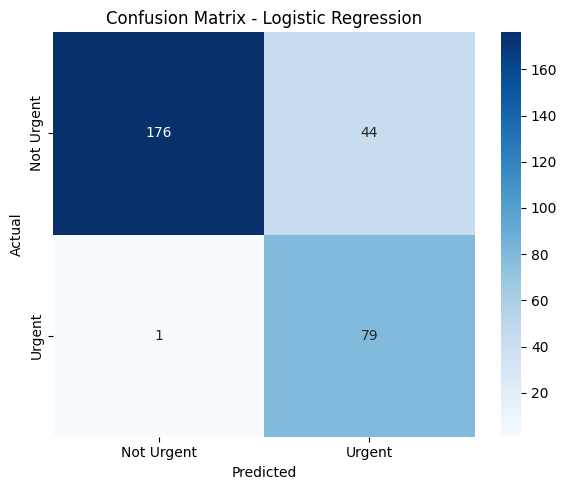

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Task 3: TF-IDF Vectorization
X = df['clean_text']
y = df['urgent_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape:", X_train_tfidf.shape)

# Task 4: Baseline Model - Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred = lr_model.predict(X_test_tfidf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Urgent','Urgent'],
            yticklabels=['Not Urgent','Urgent'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/model_evaluation.png')
plt.show()

## Task 3: Text Vectorization
TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical vectors by weighing words by how often they appear in a document vs the whole corpus. Text must be vectorized because ML models only work with numbers, not raw strings.

## Task 4: Baseline Model — Logistic Regression with TF-IDF
- **Accuracy:** 85%
- **Urgent class recall:** 0.99 — catches almost all urgent tickets
- **Macro F1:** 0.83

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Task 5: LSTM Sequence Model
MAX_WORDS = 5000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

# Build LSTM
lstm_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

history = lstm_model.fit(
    X_train_seq, y_train,
    epochs=10, batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:3},
    verbose=1
)

loss, acc = lstm_model.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nLSTM Test Accuracy: {acc:.4f}")

y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_lstm))

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8271 - loss: 0.9316 - val_accuracy: 0.8542 - val_loss: 0.5087
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8823 - loss: 0.5005 - val_accuracy: 0.8500 - val_loss: 0.2928
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8802 - loss: 0.3400 - val_accuracy: 0.8500 - val_loss: 0.2421
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8698 - loss: 0.2975 - val_accuracy: 0.8417 - val_loss: 0.2349
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8708 - loss: 0.2782 - val_accuracy: 0.8458 - val_loss: 0.2301
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8823 - loss: 0.2825 - val_accuracy: 0.8500 - val_loss: 0.2464
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8802 - loss: 0.2685 - val_accuracy: 0.8625 - val_loss: 0.2592
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8729 - loss: 0.2975 - val_accuracy: 0.8667 - v

## Task 5: LSTM Sequence Model
- Embedding layer (64 dims) → SpatialDropout → LSTM (64 units) → Dense sigmoid output
- **LSTM Test Accuracy: 85.33%** — matches baseline Logistic Regression
- For short texts like customer messages, TF-IDF + Logistic Regression performs comparably to LSTM
- LSTM would show more advantage on longer, more complex text sequences

## Task 6: Attention and Transformer Reflection
- **RNNs and long-term dependencies:** RNNs process sequences step by step. Over long sequences, gradients vanish during backpropagation, making it hard to retain information from early tokens.
- **LSTMs:** Solve this with gating mechanisms (input, forget, output gates) that control what information to keep or discard across time steps.
- **Attention:** Allows the model to directly focus on any part of the input sequence regardless of distance, solving the bottleneck of compressing everything into one hidden state.
- **Transformers:** Use self-attention entirely, processing all tokens in parallel. This enables training on massive datasets and powers modern LLMs like GPT and BERT used in Generative AI.

In [5]:
# Save sample predictions
sample_texts = X_test.iloc[:5].tolist()
sample_preds = y_pred[:5]
sample_actual = y_test.iloc[:5].tolist()

with open('results/sample_predictions.txt', 'w') as f:
    for text, pred, actual in zip(sample_texts, sample_preds, sample_actual):
        f.write(f"Text: {text}\nPredicted: {pred} | Actual: {actual}\n\n")

print("Sample predictions saved!")

Sample predictions saved!
